# Notebook for Loading and Plotting Degradation Data
#### Created in October 2022 by Dr Niall Kirkaldy for use with data in the Zenodo repository: 10.5281/zenodo.7235858
#### Updated in October 2023 by Dr Niall Kirkaldy for use with data in the Zenodo repository: 10.5281/zenodo.10637534
-------------------------

This notebook was made to aid in the further use of the lithium-ion battery cycle ageing data saved in the Zenodo repository 10.5281/zenodo.10637534 and detailed in the related publication in the Journal of Power Sources 10.1016/j.jpowsour.2024.234185 . Details of the license agreements can be found on these links.

This notebook was written in python 3.8.3 and requires pandas (1.0.5) and matplotlib (3.2.2) libraries.

---------------------------

## How-to:

----------------------

Prior to running the code in this notebook, you should download the data from Zenodo via the link above and unzip the folder. You will be asked to enter the directory where the data is saved; this should include the name of the (unzipped) folder called 'Battery Degradation Data'. If this notebook is saved in the same folder as the data, the input box can be left blank.

e.g., 'C:\Users\Niall\Imperial College London\LGM50 dataset - ME - General'

No other input should be required. Running the subsequent cells will load the data into a multi-level dictionary and plot some useful variables. There is quite a lot of data, so can take some time to load. If you only want data from a specific experiment, edit the top-level loop to only iterate over desired values (e.g. ['expt 1', 'expt 4']).

--------------------------

#### The structure of the data dictionary (called 'data_dict') is as follows:

    data_dict is a dictionary object with five keys: ['expt 1', 'expt 2,2', 'expt 3', 'expt 4', 'expt 5'].

    1. Each key has 3 sub-dictionaries: ['Main', 'Ageing', 'Timeseries'], which contain the different types of data as described in the repository on Zenodo. In all cases, the keys in these dictionaries are the cell IDs (i.e. 'A', 'B', etc.). These can also be viewed in the 'experiment_metadata' excel file.
    
        1.1 'Main' contains a dictionary of pandas DataFrame objects (one entry for each cell tested). These DataFrames house most of the important degradation data, such as charge throughput, capacity fade, resistance increase, and the degradation modes determined from OCV-fitting of the C/10 discharge data from each RPT. 
        E.g. data_dict['expt 1']['Main']['A'] is a DataFrame with the data for cell A of experiment 1 (0-30% SoC cycling). 
        This has the general form: data_dict[EXPERIMENT]['Main'][CELL_ID]
        
        1.2 'Ageing' similarly contains a dictionary of pandas DataFrame objects (one entry for each cell tested). These DataFrames house summary variables from the ageing sets, such as average temperature during discharge, etc. Each row corresponds to a different ageing set. Alternatively, there are similar variables available on a per-cycle basis in the same folder (not loaded here). 
        E.g. data_dict['expt 5']['Ageing']['H'] is a DataFrame with operating variables which have been averaged over each ageing set for cell 'H' of experiment 5 (0-100% SoC cycling). 
        This has the general form: data_dict[EXPERIMENT]['Ageing'][CELL_ID]
        
        1.3 'Timeseries' contains the raw timeseries data for each cell at each reference performance test (RPT).As above, there is one entry per cell. However, each entry contains a list with each RPT for that cell. For each RPT there is a further list which contains raw data for each of the multiple sub-tests of the RPT (saved as pandas DataFrames). 
        E.g. data_dict['expt 1']['Timeseries']['E'][4][0] is a DataFrame with the C/10 discharge data at RPT 4 for cell E in experiment 1 (0-30% SoC cycling). 
        The general form is data_dict[EXPERIMENT]['Timeseries'][CELL_ID][RPT_NUMBER][SUB_TEST]. Details on the subtests can be found in the publication in the Journal of Power Sources and in the Zenodo repository.
        

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
# You can leave blank if this notebook is saved in root directory of data
root_filepath = "/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data"

In [3]:
if len(root_filepath) > 0:
    root_filepath += '/'
main_data_path = 'Summary Data'

# Read metadata from excel file
meta_data_dict = {}
expt_list = ['expt 5']
for expt in expt_list:
    meta_data = pd.read_excel(f'{root_filepath}experiment_metadata.xlsx', sheet_name=f'{expt}')
    meta_data.set_index('Cell', inplace=True, drop=False)
    meta_data_dict[expt] = meta_data

# Define colours for plotting data later.  
colour_temp_dict = {10:'C0', 25:'C1', 40:'C3'}

In [4]:
data_dict = {}
# Edit the top-level 'for' loop if you don't want to load data from all expts
for expt in meta_data_dict.keys():
    long_name = meta_data_dict[expt].loc['A', 'Expt long name']
    SoC_range = meta_data_dict[expt].loc['A', 'SoC range']
    main_data = {}
    age_set_data = {}
    timeseries_data = {}
    # Edit the next 'for' loop if you don't want to load data from all cells (within current expt)
    for cell in meta_data_dict[expt].index.values:
        temp_val = meta_data_dict[expt].loc[cell, 'Temp']
        cell_ID = meta_data_dict[expt].loc[cell, 'Cell']
        main_data[cell_ID] = pd.read_csv(f'{root_filepath}{long_name}/{main_data_path}/Performance Summary/Expt {expt[5:]} - cell {cell_ID} ({temp_val}degC) - Processed Data.csv', index_col=0)
        age_set_data[cell_ID] = pd.read_csv(f'{root_filepath}{long_name}/{main_data_path}/Ageing Sets Summary/Summary per Cycle/expt {expt[5:]} - cell {cell_ID} - cycle_data.csv', index_col=0)
        cell_timeseries_data = []
        # for rpt in range(len(main_data[cell_ID])):
        #     #Even-numbered RPTs have 4 sub-tests, whereas odd-numbered RPTs have 3.
        #     if rpt % 2 == 0:
        #         CC_0p1C = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/0.1C Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - 0.1C discharge data.csv')
        #         CC_0p5C = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/0.5C Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - 0.5C discharge data.csv')
        #         GITT_25p = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/GITT Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - 25-pulse GITT 0.5C discharge data.csv')
        #         GITT_5p = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/GITT Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - 5-pulse GITT 0.5C discharge data.csv')
        #         cell_timeseries_data.append([CC_0p1C, CC_0p5C, GITT_25p, GITT_5p])
        #     else:
        #         CC_0p1C = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/0.1C Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - 0.1C discharge data.csv')
        #         hybrid_pulse_0p5C = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/Hybrid CC-Pulse Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - Hybrid CC-Pulse 0.5C discharge data.csv')
        #         hybrid_pulse_1C = pd.read_csv(f'{root_filepath}{long_name}/Processed Timeseries Data/Hybrid CC-Pulse Voltage Curves/cell {cell_ID}/Expt {expt[5:]} - cell {cell_ID} - RPT{rpt} - Hybrid CC-Pulse 1C discharge data.csv')
        #         cell_timeseries_data.append([CC_0p1C, hybrid_pulse_0p5C, hybrid_pulse_1C])
        # timeseries_data[cell_ID] = cell_timeseries_data
    data_dict[expt] = {'Main':main_data, 'Ageing':age_set_data, 'Timeseries':timeseries_data}

## View dataframes

An example of each of the types of data from the 'Extracted Data' folder, as detailed above.

Main: Summary data for each cell.

Timeseries: raw data from each section of each RPT.

Ageing: Summary variables from the cycle ageing (for each cell at each ageing set).

In [25]:
# data_dict['expt 4']['Main']['C']

In [26]:
# data_dict['expt 5']['Timeseries']['A'][0][0]

In [5]:
data_dict['expt 5']['Ageing']['E']

,Discharge Capacity [A h],Charge Capacity [A h],Av. Discharge Temperature [°C],Min. Discharge Temperature [°C],Max. Discharge Temperature [°C],Av. Discharge Voltage [V],Min. Discharge Voltage [V],Av. Charge Temperature [°C],Min. Charge Temperature [°C],Max. Charge Temperature [°C],Av. Charge Voltage [V],Max. Charge Voltage [V],Charge Efficiency,Voltage Range [V],Charge Throughput [A h]
Cycle,,,,,,,,,,,,,,,
0.0,4.689392,3.145620,32.402813,24.402632,37.505386,3.459369,2.499968,25.511240,24.016560,27.900900,4.121920,4.200292,1.490769,1.700324,7.835012
1.0,4.662913,4.707837,26.559017,25.442656,36.875070,3.998449,2.499968,27.686037,-3.071408,37.631450,3.893305,4.200331,0.990458,1.700363,17.205762
2.0,4.677770,4.695769,32.154156,26.592989,37.072044,3.464209,2.499968,27.698133,26.175404,36.882946,3.894662,4.200292,0.996167,1.700324,26.579301
3.0,4.672137,4.691181,32.263023,26.553595,37.064163,3.464474,2.499968,27.849602,26.317223,37.324170,3.894631,4.200331,0.995940,1.700363,35.942619
4.0,4.666396,4.685192,32.135150,26.388134,36.906580,3.464065,2.499968,27.849195,26.269950,37.292656,3.895021,4.200331,0.995988,1.700363,45.294207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1146.0,3.687308,3.697454,32.116657,25.497736,36.899580,3.423192,2.499944,26.414955,25.056477,36.970497,4.001888,4.200049,0.997256,1.700105,9452.657033
1147.0,3.685933,3.696270,32.017334,25.261347,36.970497,3.422542,2.499983,26.425762,25.135271,36.915340,4.002160,4.200049,0.997204,1.700066,9460.039236
1148.0,3.685221,3.695525,31.984310,25.300747,36.931100,3.422518,2.499983,26.444948,25.032839,36.994137,4.001923,4.200089,0.997212,1.700105,9467.419982


## Plot some of the data

Example plots for each of the types of data from the 'Summary Data' and 'Processed Timeseries Data' folders (timeseries, main, ageing).

In [28]:
# fig_timeseries, ax = plt.subplots(2, figsize=(8, 10), sharex=True)

# # Edit the value of 'expt' if you want to plot for a different expt.
# expt = 'expt 5'
# # Edit the value of 'cell' if you want to plot for a different cell.
# cell = 'E'

# x_variable_1 = 'Charge (mA.h)'
# y_variable_1 = 'Voltage (V)'
# x_variable_2 = x_variable_1
# y_variable_2 = y_variable_1

# for rpt in range(len(data_dict[expt]['Timeseries'][cell])):
#     # Plot C/10 discharge data
#     data_dict[expt]['Timeseries'][cell][rpt][0].plot(x_variable_1, y_variable_1, ax=ax[0], c='k', alpha=(1-rpt/len(data_dict[expt]['Timeseries'][cell])), label=f'RPT {rpt}')
#     if rpt % 2 == 0:
#         # Some RPT data is only available on even or odd numbered RPTs (e.g. GITT)
#         data_dict[expt]['Timeseries'][cell][rpt][2].plot(x_variable_2, y_variable_2, ax=ax[1], c='k', alpha=(1-rpt/len(data_dict[expt]['Timeseries'][cell])), label=f'RPT {rpt}')
    
# #ax[0].set_xlabel(x_variable_1)
# ax[0].set_ylabel(y_variable_1)
# ax[1].set_xlabel(x_variable_2)
# ax[1].set_ylabel(y_variable_2)

# age_temp = meta_data_dict[expt].loc[cell, 'Temp']
# age_SoC = meta_data_dict[expt].loc[cell, 'SoC range']
# ax[0].set_title(f'V vs Q data for {expt} cell {cell} (cycled at {age_SoC}% SoC / {age_temp} degC)')

# fig_timeseries.tight_layout()

In [29]:
# fig_ageing, ax = plt.subplots(2, sharex=True)

# # Edit the value of 'expt' if you want to plot for a different expt.
# expt = '5'
# # Can plot as a function of other x-variables (e.g. 'Ageing Cycles', or 'Days of degradation').
# x_variable = 'Charge Throughput [A h]'
# y_variable_1 = 'C/10 Capacity [mA h]'
# y_variable_2 = '0.1s Resistance [Ohms]'

# for cell in meta_data_dict[expt].index.values:
#     temp_val = meta_data_dict[expt].loc[cell, 'Temp']
#     data_dict[expt]['Main'][cell].plot(x_variable, y_variable_1, ax=ax[0], c=colour_temp_dict[temp_val], marker='o')
#     # Resistance values from GITT, so only avaiable on even-numbered RPTs
#     df_slice = data_dict[expt]['Main'][cell].loc[range(0,len(data_dict[expt]['Main'][cell]), 2), :]
#     df_slice.plot(x_variable, y_variable_2, ax=ax[1], c=colour_temp_dict[temp_val], marker='o')

# ax[1].set_xlabel(x_variable)
# ax[0].set_ylabel(y_variable_1)
# ax[1].set_ylabel(y_variable_2)
# ax[0].grid(True)
# ax[1].grid(True)
# SOC_val = meta_data_dict[expt].loc[cell, 'SoC range']
# ax[0].set_title(f'Ageing Data for cells cycled at {SOC_val}% SoC')

# colours = colour_temp_dict
# labels = [f'{temp_value} degC' for temp_value in colour_temp_dict.keys()]
# handles = [plt.Rectangle((0,0),1,1, color=colours[temp_value]) for temp_value in colour_temp_dict.keys()]
# ax[0].legend(handles, labels, loc='best')
# ax[1].legend(handles, labels, loc='best')

# fig_ageing.tight_layout()

In [30]:
# fig_DMA, ax = plt.subplots(6, figsize=(8,10), sharex=True)

# # Edit the value of 'expt' if you want to plot for a different expt.
# expt = 'expt 5'
# # Can plot as a function of other x-variables (e.g. 'Ageing Cycles', or 'Days of degradation').
# x_variable = 'Charge Throughput [A h]'

# for cell in meta_data_dict[expt].index.values:
#     temp_val = meta_data_dict[expt].loc[cell, 'Temp']
#     # Take x-axis values from 'Main'
#     x_values = data_dict[expt]['Main'][cell].loc[:,x_variable]
#     # Plot all available DMA variables (on separate axes)
#     for number, key in enumerate(['SoH', 'LAM PE', 'LAM NE_tot', 'LAM NE_Gr', 'LAM NE_Si', 'LLI']):
#         ax[number].plot(x_values, data_dict[expt]['Main'][cell].loc[:,key], c=colour_temp_dict[temp_val], marker='o')
#         ax[number].set_ylabel(key)
#         ax[number].grid(True)

# ax[5].set_xlabel(x_variable)
# SOC_val = meta_data_dict[expt].loc[cell, 'SoC range']
# ax[0].set_title(f'DMA analysis for cells cycled at {SOC_val}% SoC')

# colours = colour_temp_dict
# labels = [f'{temp_value} degC' for temp_value in colour_temp_dict.keys()]
# handles = [plt.Rectangle((0,0),1,1, color=colours[temp_value]) for temp_value in colour_temp_dict.keys()]
# ax[0].legend(handles, labels, loc='best')

# fig_DMA.tight_layout()

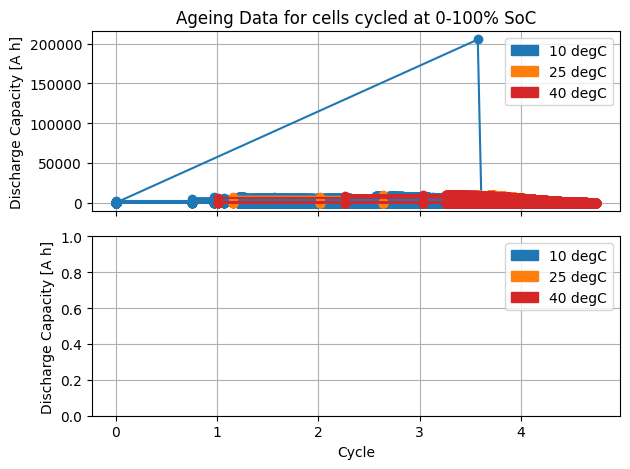

In [9]:
fig_ageing, ax = plt.subplots(2, sharex=True)

# Edit the value of 'expt' if you want to plot for a different expt.
expt = 'expt 5'
cell = 'E'
# Can plot as a function of other x-variables (e.g. 'Ageing Cycles', or 'Days of degradation').
x_variable = 'Cycle'
y_variable_1 = 'Discharge Capacity [A h]'
y_variable_2 = 'Discharge Capacity [A h]'

for cell in meta_data_dict[expt].index.values:
    temp_val = meta_data_dict[expt].loc[cell, 'Temp']
    data_dict[expt]['Ageing'][cell].plot( y_variable_1, ax=ax[0], c=colour_temp_dict[temp_val], marker='o')
    # data_dict[expt]['Ageing'][cell].plot( y_variable_1, ax=ax[1], c=colour_temp_dict[temp_val], marker='o')
    # Resistance values from GITT, so only avaiable on even-numbered RPTs
    # df_slice = data_dict[expt]['Ageing'][cell].loc[range(0,len(data_dict[expt]['Ageing'][cell]), 2), :]
    # df_slice.plot(x_variable, y_variable_2, ax=ax[1], c=colour_temp_dict[temp_val], marker='o')

ax[1].set_xlabel(x_variable)
ax[0].set_ylabel(y_variable_1)
ax[1].set_ylabel(y_variable_2)
ax[0].grid(True)
ax[1].grid(True)
SOC_val = meta_data_dict[expt].loc[cell, 'SoC range']
ax[0].set_title(f'Ageing Data for cells cycled at {SOC_val}% SoC')

colours = colour_temp_dict
labels = [f'{temp_value} degC' for temp_value in colour_temp_dict.keys()]
handles = [plt.Rectangle((0,0),1,1, color=colours[temp_value]) for temp_value in colour_temp_dict.keys()]
ax[0].legend(handles, labels, loc='best')
ax[1].legend(handles, labels, loc='best')

fig_ageing.tight_layout()

plt.show()

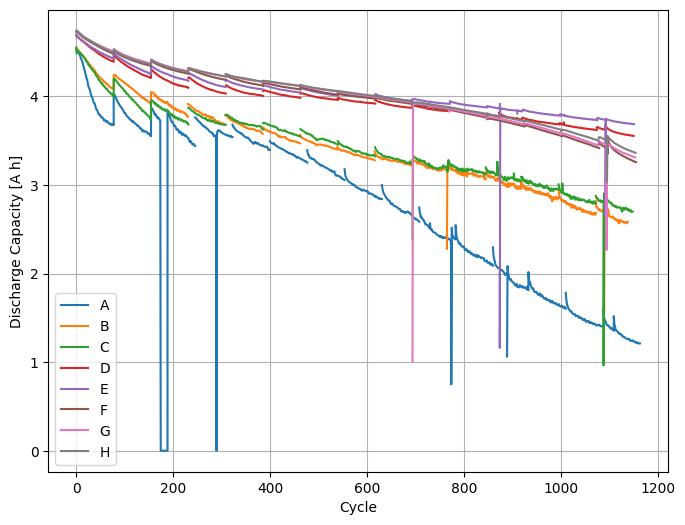

In [10]:
plt.figure(figsize=(8,6))

for cell in data_dict[expt]['Ageing']:

    df = data_dict[expt]['Ageing'][cell]

    plt.plot(df.index,
             df['Discharge Capacity [A h]'],
             label=cell)

plt.xlabel("Cycle")
plt.ylabel("Discharge Capacity [A h]")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import os
current_directory = os.getcwd()
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data'

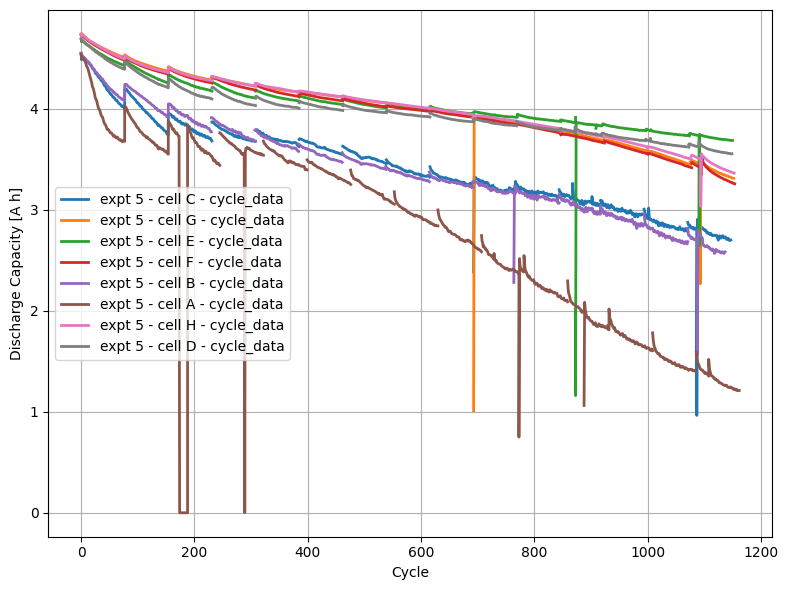

In [14]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

folder = f"{current_directory}/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle"

files = glob.glob(os.path.join(folder, "*.csv"))

plt.figure(figsize=(8,6))

for file in files:

    df = pd.read_csv(file, index_col=0)

    label = os.path.basename(file).replace(".csv","")

    plt.plot(df.index,
             df['Discharge Capacity [A h]'],
             linewidth=2,
             label=label)

plt.xlabel("Cycle")
plt.ylabel("Discharge Capacity [A h]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
files

['/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell C - cycle_data.csv',
 '/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell G - cycle_data.csv',
 '/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell E - cycle_data.csv',
 '/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell F - cycle_data.csv',
 '/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell B - cycle_data.csv',
 '/home/ganmad/

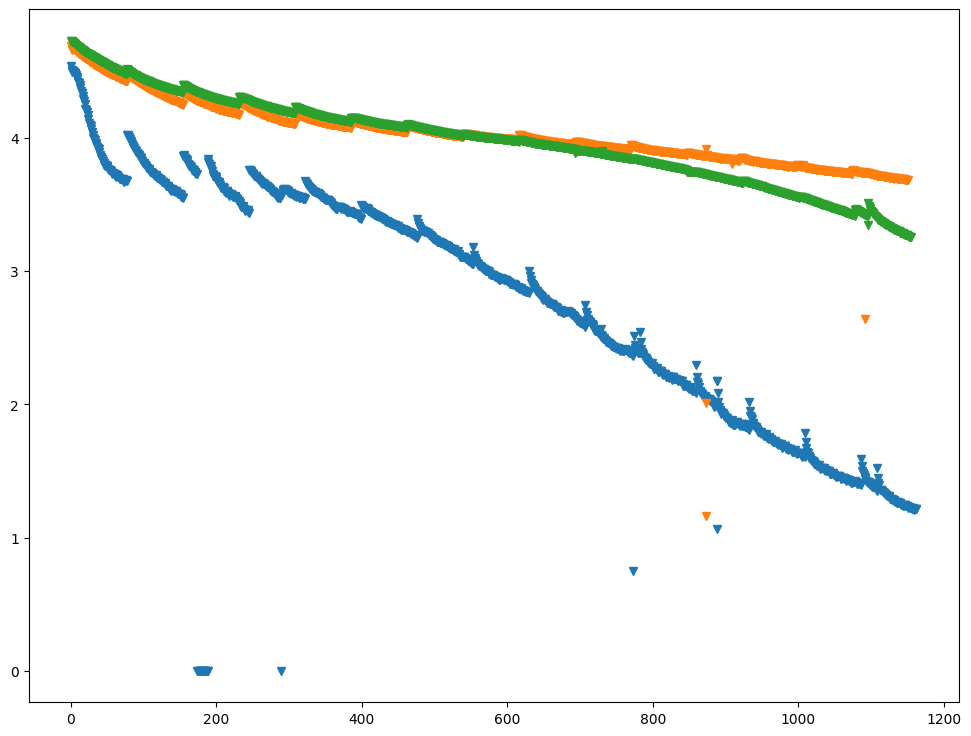

In [29]:
plt.figure(figsize=(12,9))
for m in ["A", "E", "F"]:
    df4 = pd.read_csv(f"{current_directory}//Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell {m} - cycle_data.csv")
    plt.plot(df4["Cycle"], df4['Discharge Capacity [A h]'], linestyle="None", marker='v', linewidth=1, label =f"cell {m}") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")
plt.show()

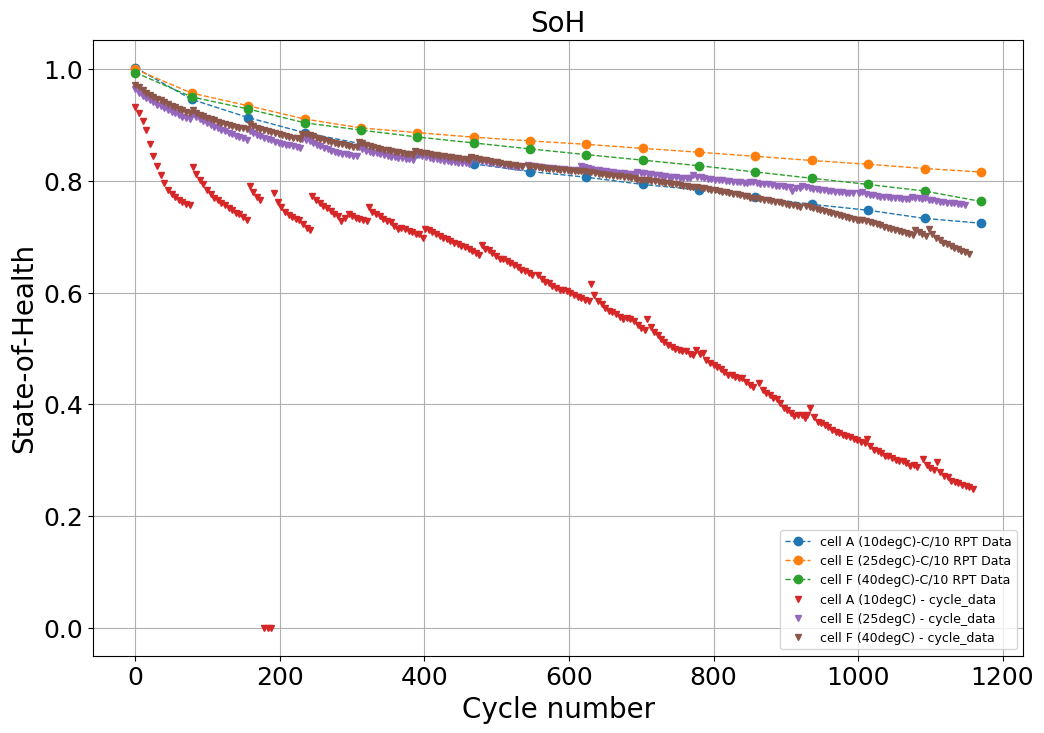

In [51]:
plt.figure(figsize=(12,8))
for m in ["A (10degC)", "E (25degC)", "F (40degC)"]:
    df5 = pd.read_csv(f"{current_directory}//Expt 5 - Standard Cycle Aging (Control)/Summary Data//Performance Summary/Expt 5 - cell {m} - Processed Data.csv")
    plt.plot(df5['Ageing Cycles'], df5['C/10 Capacity [mA h]']/1000/4.865, linestyle="--", marker='o',  linewidth=1, label =f"cell {m}-C/10 RPT Data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in ["A", "E", "F"]:
    if m == "A":
        n = "(10degC)"
    if m == "E":
        n = "(25degC)"
    if m == "F":
        n = "(40degC)"
    
    df4 = pd.read_csv(f"{current_directory}//Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell {m} - cycle_data.csv")
    plt.plot(df4["Cycle"], df4['Discharge Capacity [A h]']/4.865, linestyle="None", marker='v',markevery=5,markersize=4, linewidth=0.5, label =f"cell {m} {n} - cycle_data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
plt.title('SoH',fontsize=20)
#plt.ylim([70, 102])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()
